In [ ]:
!wget -O SensorData.zip "https://zenodo.org/records/14988663/files/SensorData%282%29.zip?download=1"

--2026-09-04 13:29:54--  https://zenodo.org/records/14988663/files/SensorData%282%29.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.98.114, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13285030 (13M) [application/octet-stream]
Saving to: ‘SensorData.zip’

SensorData.zip      100%[===================>]  12.67M   560KB/s    in 22s     

2026-09-04 13:30:17 (588 KB/s) - ‘SensorData.zip’ saved [13285030/13285030]



In [ ]:
!ls -lh

total 13M
drwxr-xr-x 1 root root 4.0K Aug 24 13:21 sample_data
-rw-r--r-- 1 root root  13M Sep  4 13:30 SensorData.zip


In [ ]:
!unzip -q SensorData.zip -d waste_data

In [ ]:
import os

for root, dirs, files in os.walk("waste_data"):
    print(root)
    print(files[:10])
    break

waste_data
[]


In [ ]:
import os
import pandas as pd

# Find INFO.csv anywhere inside the extracted folder
info_path = None

for root, dirs, files in os.walk("waste_data"):
    for file in files:
        if file.lower() == "info.csv":
            info_path = os.path.join(root, file)

print("INFO.csv path:", info_path)

# Load it
info_df = pd.read_csv(info_path)

print("Shape:", info_df.shape)
info_df.head()

INFO.csv path: waste_data/Deliver_data/INFO.csv
Shape: (484, 5)


,ID,Capacity,WasteType,Latitude,Longitude
0,7252.0,2500.0,Embalagens de papel e cartão,39.284250,-8.879333
1,10130.0,2500.0,Embalagens de papel e cartão,39.332019,-8.940211
2,2336.0,2500.0,Embalagens de papel e cartão,39.343505,-8.937782
3,18761.0,2500.0,Embalagens de papel e cartão,39.420554,-8.906472
4,11984.0,2500.0,Embalagens de papel e cartão,39.337367,-8.934347


In [ ]:
print("Columns:")
print(info_df.columns.tolist())

print("\nDataset Info:")
info_df.info()

Columns:
['ID', 'Capacity', 'WasteType', 'Latitude', 'Longitude']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         484 non-null    float64
 1   Capacity   484 non-null    float64
 2   WasteType  484 non-null    object 
 3   Latitude   484 non-null    float64
 4   Longitude  484 non-null    float64
dtypes: float64(4), object(1)
memory usage: 19.0+ KB


In [ ]:
info_df.describe(include="all")

,ID,Capacity,WasteType,Latitude,Longitude
count,484.000000,484.000000,484,484.000000,484.000000
unique,NaN,NaN,2,NaN,NaN
top,NaN,NaN,Embalagens de papel e cartão,NaN,NaN
freq,NaN,NaN,243,NaN,NaN
mean,9842.090909,2589.876033,NaN,39.331856,-8.914091
std,5192.983905,461.432625,NaN,0.042377,0.044595
min,192.000000,2500.000000,NaN,39.246647,-8.998756
25%,6239.250000,2500.000000,NaN,39.299469,-8.940442
50%,10177.000000,2500.000000,NaN,39.335056,-8.929620
75%,11984.500000,2500.000000,NaN,39.348279,-8.888933


In [ ]:
import glob

# Find all corrected fill files
fill_files = glob.glob("waste_data/**/*fill_Corrected*.csv", recursive=True)

print("Number of corrected fill files:", len(fill_files))

print("\nFirst 5 files:")
for f in fill_files[:5]:
    print(f)

Number of corrected fill files: 484

First 5 files:
waste_data/Deliver_data/Container_1857_fill_Corrected_with_metrics.csv
waste_data/Deliver_data/Container_11862_fill_Corrected_with_metrics.csv
waste_data/Deliver_data/Container_12655_fill_Corrected_with_metrics.csv
waste_data/Deliver_data/Container_6908_fill_Corrected_with_metrics.csv
waste_data/Deliver_data/Container_6236_fill_Corrected_with_metrics.csv


In [ ]:
# Load the first corrected fill file
sample_fill = pd.read_csv(fill_files[0])

print("File:", fill_files[0])
print("\nShape:", sample_fill.shape)

print("\nColumns:")
print(sample_fill.columns.tolist())

sample_fill.head()

File: waste_data/Deliver_data/Container_1857_fill_Corrected_with_metrics.csv

Shape: (1268, 7)

Columns:
['Date', 'Fill', 'Rec', 'Cidx', 'Max', 'Min', 'Mean']


,Date,Fill,Rec,Cidx,Max,Min,Mean
0,2021-01-01 17:23:00,46,0,NaN,NaN,NaN,NaN
1,2021-01-02 02:02:00,33,0,NaN,NaN,NaN,NaN
2,2021-01-02 14:14:00,42,0,NaN,NaN,NaN,NaN
3,2021-01-02 17:49:00,56,0,NaN,NaN,NaN,NaN
4,2021-01-02 18:51:00,73,0,NaN,NaN,NaN,NaN


In [ ]:
print(sample_fill["Rec"].value_counts())
sample_fill.groupby("Rec")["Fill"].describe()
sample_fill[sample_fill["Rec"] == 1].head(20)

Rec
0    1237
1      31
Name: count, dtype: int64


,Date,Fill,Rec,Cidx,Max,Min,Mean
12,2021-01-05 18:37:00,2,1,0.0,2.0,2.0,2.0
66,2021-02-15 20:05:00,0,1,1.0,0.0,0.0,0.0
86,2021-03-01 18:41:00,4,1,2.0,4.0,0.0,2.0
129,2021-04-01 19:02:00,12,1,3.0,12.0,3.0,7.5
163,2021-04-26 21:35:00,17,1,4.0,17.0,5.0,11.0
191,2021-05-17 21:02:00,11,1,5.0,11.0,6.0,8.5
217,2021-06-10 18:33:00,12,1,6.0,12.0,4.0,8.0
245,2021-06-30 21:12:00,12,1,7.0,12.0,6.0,9.0
299,2021-08-04 19:51:00,16,1,8.0,16.0,2.0,9.0
360,2021-09-23 17:56:00,8,1,10.0,8.0,1.0,4.5


In [ ]:
sample_fill["Date"] = pd.to_datetime(sample_fill["Date"])

print("Start date:", sample_fill["Date"].min())
print("End date:", sample_fill["Date"].max())

print("\nFill range:")
print("Minimum:", sample_fill["Fill"].min())
print("Maximum:", sample_fill["Fill"].max())

print("\nAverage fill:")
print(sample_fill["Fill"].mean())

Start date: 2021-01-01 17:23:00
End date: 2023-09-19 14:02:00

Fill range:
Minimum: 0
Maximum: 100

Average fill:
32.43769716088328


In [ ]:
import glob
import os
import pandas as pd

fill_files = glob.glob(
    "waste_data/**/*fill_Corrected*.csv",
    recursive=True
)

print("Number of corrected files:", len(fill_files))

all_data = []

for file in fill_files:

    # Extract container ID from filename
    filename = os.path.basename(file)
    container_id = filename.split("_")[1]

    df = pd.read_csv(file)

    df["Container_ID"] = container_id

    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

print("Combined shape:", combined_df.shape)

combined_df.head()

Number of corrected files: 484
Combined shape: (788595, 8)


,Date,Fill,Rec,Cidx,Max,Min,Mean,Container_ID
0,2021-01-01 17:23:00,46,0,NaN,NaN,NaN,NaN,1857
1,2021-01-02 02:02:00,33,0,NaN,NaN,NaN,NaN,1857
2,2021-01-02 14:14:00,42,0,NaN,NaN,NaN,NaN,1857
3,2021-01-02 17:49:00,56,0,NaN,NaN,NaN,NaN,1857
4,2021-01-02 18:51:00,73,0,NaN,NaN,NaN,NaN,1857


In [ ]:
combined_df["Date"] = pd.to_datetime(combined_df["Date"])

combined_df["Fill"] = pd.to_numeric(
    combined_df["Fill"],
    errors="coerce"
)

combined_df["Container_ID"] = pd.to_numeric(
    combined_df["Container_ID"],
    errors="coerce"
)

combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788595 entries, 0 to 788594
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          788595 non-null  datetime64[ns]
 1   Fill          788595 non-null  int64         
 2   Rec           788595 non-null  int64         
 3   Cidx          771972 non-null  float64       
 4   Max           771495 non-null  float64       
 5   Min           771495 non-null  float64       
 6   Mean          771495 non-null  float64       
 7   Container_ID  788595 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 48.1 MB


In [ ]:
print("Total readings:", len(combined_df))
print("Total containers:", combined_df["Container_ID"].nunique())

print("\nDate range:")
print(combined_df["Date"].min())
print(combined_df["Date"].max())

print("\nFill level statistics:")
print(combined_df["Fill"].describe())

print("\nCollection indicator:")
print(combined_df["Rec"].value_counts())

Total readings: 788595
Total containers: 484

Date range:
2021-01-01 00:01:00
2023-10-23 20:41:00

Fill level statistics:
count    788595.000000
mean         36.999257
std          27.496988
min           0.000000
25%          12.000000
50%          33.000000
75%          55.000000
max         100.000000
Name: Fill, dtype: float64

Collection indicator:
Rec
0    757333
1     31262
Name: count, dtype: int64


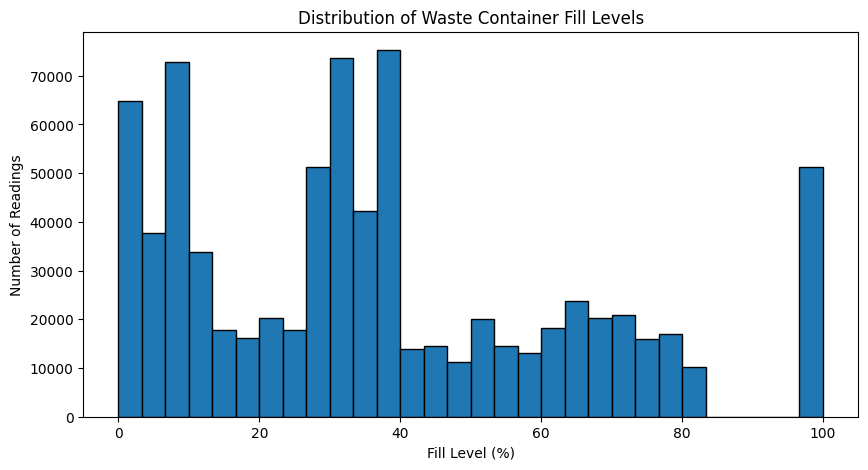

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(combined_df["Fill"], bins=30, edgecolor="black")

plt.xlabel("Fill Level (%)")
plt.ylabel("Number of Readings")
plt.title("Distribution of Waste Container Fill Levels")

plt.show()

In [ ]:
CRITICAL_LEVEL = 80

critical = combined_df[
    combined_df["Fill"] >= CRITICAL_LEVEL
]

print("Critical readings (>= 80%):", len(critical))
print(
    "Percentage of critical readings:",
    round(len(critical) / len(combined_df) * 100, 2),
    "%"
)

Critical readings (>= 80%): 61443
Percentage of critical readings: 7.79 %


In [ ]:
combined_df = combined_df.sort_values(
    ["Container_ID", "Date"]
).reset_index(drop=True)

combined_df.head()

,Date,Fill,Rec,Cidx,Max,Min,Mean,Container_ID
0,2021-01-01 10:38:00,1,0,NaN,NaN,NaN,NaN,192
1,2021-01-02 10:25:00,1,0,NaN,NaN,NaN,NaN,192
2,2021-01-03 10:12:00,1,0,NaN,NaN,NaN,NaN,192
3,2021-01-03 13:12:00,12,0,NaN,NaN,NaN,NaN,192
4,2021-01-04 10:00:00,12,0,NaN,NaN,NaN,NaN,192


In [ ]:
combined_df["Next_Fill"] = (
    combined_df
    .groupby("Container_ID")["Fill"]
    .shift(-1)
)

combined_df["Critical_Next"] = (
    combined_df["Next_Fill"] >= 80
).astype(int)

combined_df[[
    "Container_ID",
    "Date",
    "Fill",
    "Next_Fill",
    "Critical_Next"
]].head(10)

,Container_ID,Date,Fill,Next_Fill,Critical_Next
0,192,2021-01-01 10:38:00,1,1.0,0
1,192,2021-01-02 10:25:00,1,1.0,0
2,192,2021-01-03 10:12:00,1,12.0,0
3,192,2021-01-03 13:12:00,12,12.0,0
4,192,2021-01-04 10:00:00,12,12.0,0
5,192,2021-01-05 09:47:00,12,12.0,0
6,192,2021-01-06 09:34:00,12,12.0,0
7,192,2021-01-07 09:20:00,12,12.0,0
8,192,2021-01-08 09:07:00,12,11.0,0
9,192,2021-01-09 02:58:00,11,11.0,0


In [ ]:
combined_df = combined_df.dropna(
    subset=["Next_Fill"]
).copy()

print("New shape:", combined_df.shape)

print("\nTarget distribution:")
print(combined_df["Critical_Next"].value_counts())

print("\nPercentage:")
print(
    combined_df["Critical_Next"]
    .value_counts(normalize=True)
    * 100
)

New shape: (788111, 10)

Target distribution:
Critical_Next
0    726721
1     61390
Name: count, dtype: int64

Percentage:
Critical_Next
0    92.210488
1     7.789512
Name: proportion, dtype: float64


In [ ]:
# Previous fill level
combined_df["Previous_Fill"] = (
    combined_df
    .groupby("Container_ID")["Fill"]
    .shift(1)
)

# Change in fill level
combined_df["Fill_Change"] = (
    combined_df["Fill"]
    - combined_df["Previous_Fill"]
)

# Time-based features
combined_df["Hour"] = combined_df["Date"].dt.hour

combined_df["Day_of_Week"] = (
    combined_df["Date"].dt.dayofweek
)

combined_df["Month"] = (
    combined_df["Date"].dt.month
)

# Rolling average of previous 3 readings
combined_df["Rolling_Mean_3"] = (
    combined_df
    .groupby("Container_ID")["Fill"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

combined_df.head(10)

,Date,Fill,Rec,Cidx,Max,Min,Mean,Container_ID,Next_Fill,Critical_Next,Previous_Fill,Fill_Change,Hour,Day_of_Week,Month,Rolling_Mean_3
0,2021-01-01 10:38:00,1,0,NaN,NaN,NaN,NaN,192,1.0,0,NaN,NaN,10,4,1,NaN
1,2021-01-02 10:25:00,1,0,NaN,NaN,NaN,NaN,192,1.0,0,1.0,0.0,10,5,1,NaN
2,2021-01-03 10:12:00,1,0,NaN,NaN,NaN,NaN,192,12.0,0,1.0,0.0,10,6,1,NaN
3,2021-01-03 13:12:00,12,0,NaN,NaN,NaN,NaN,192,12.0,0,1.0,11.0,13,6,1,1.000000
4,2021-01-04 10:00:00,12,0,NaN,NaN,NaN,NaN,192,12.0,0,12.0,0.0,10,0,1,4.666667
5,2021-01-05 09:47:00,12,0,NaN,NaN,NaN,NaN,192,12.0,0,12.0,0.0,9,1,1,8.333333
6,2021-01-06 09:34:00,12,0,NaN,NaN,NaN,NaN,192,12.0,0,12.0,0.0,9,2,1,12.000000
7,2021-01-07 09:20:00,12,0,NaN,NaN,NaN,NaN,192,12.0,0,12.0,0.0,9,3,1,12.000000
8,2021-01-08 09:07:00,12,0,NaN,NaN,NaN,NaN,192,11.0,0,12.0,0.0,9,4,1,12.000000
9,2021-01-09 02:58:00,11,0,NaN,NaN,NaN,NaN,192,11.0,0,12.0,-1.0,2,5,1,12.000000


In [ ]:
model_df = combined_df.dropna(
    subset=[
        "Previous_Fill",
        "Fill_Change",
        "Rolling_Mean_3"
    ]
).copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (786659, 16)


In [ ]:
features = [
    "Fill",
    "Previous_Fill",
    "Fill_Change",
    "Hour",
    "Day_of_Week",
    "Month",
    "Rolling_Mean_3"
]

X = model_df[features]
y = model_df["Critical_Next"]

# Chronological split
split_date = model_df["Date"].quantile(0.80)

train_mask = model_df["Date"] <= split_date
test_mask = model_df["Date"] > split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Split date:", split_date)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining critical percentage:")
print(round(y_train.mean() * 100, 2), "%")

print("\nTesting critical percentage:")
print(round(y_test.mean() * 100, 2), "%")

Split date: 2023-07-13 19:23:24
Training samples: 629327
Testing samples: 157332

Training critical percentage:
7.08 %

Testing critical percentage:
10.61 %


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS\n")

print(classification_report(
    y_test,
    log_pred,
    digits=4
))

print("ROC-AUC:",
      round(roc_auc_score(y_test, log_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))


LOGISTIC REGRESSION RESULTS

              precision    recall  f1-score   support

           0     0.9930    0.8191    0.8977    140633
           1     0.3844    0.9511    0.5475     16699

    accuracy                         0.8331    157332
   macro avg     0.6887    0.8851    0.7226    157332
weighted avg     0.9284    0.8331    0.8605    157332

ROC-AUC: 0.9646

Confusion Matrix:
[[115198  25435]
 [   816  15883]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Use a sample of the training data to keep training fast
# Get the indices of the training data
train_indices = X_train.index

# Sample a subset of these indices
n_samples = min(200000, len(train_indices))
sampled_indices = train_indices.to_series().sample(n=n_samples, random_state=42).index

X_train_rf = X_train.loc[sampled_indices]
y_train_rf = y_train.loc[sampled_indices]

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("===== RANDOM FOREST RESULTS =====")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

===== RANDOM FOREST RESULTS =====
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    140633
           1       0.62      0.90      0.73     16699

    accuracy                           0.93    157332
   macro avg       0.80      0.92      0.85    157332
weighted avg       0.95      0.93      0.94    157332

Confusion Matrix:
[[131295   9338]
 [  1653  15046]]
ROC-AUC: 0.9683712555922993


In [ ]:
# Create a copy of test data, ensuring it includes all necessary original columns
priority_df = model_df[test_mask].copy()

# Get probability of becoming critical
priority_df["Critical_Probability"] = rf_model.predict_proba(
    priority_df[features]
)[:, 1]

# Normalize current fill
priority_df["Fill_Score"] = priority_df["Fill"] / 100

# Normalize fill change
priority_df["Fill_Change_Score"] = (
    priority_df["Fill_Change"].clip(lower=0) /
    priority_df["Fill_Change"].clip(lower=0).max()
)

# Create priority score
priority_df["Priority_Score"] = (
    0.50 * priority_df["Critical_Probability"] +
    0.35 * priority_df["Fill_Score"] +
    0.15 * priority_df["Fill_Change_Score"]
)

print(priority_df[
    [
        "Container_ID",
        "Date",
        "Fill",
        "Critical_Probability",
        "Priority_Score"
    ]
].head(10))

      Container_ID                Date  Fill  Critical_Probability  \
1145           192 2023-07-13 20:33:00     3              0.000423   
1146           192 2023-07-14 11:11:00     8              0.056553   
1147           192 2023-07-15 11:03:00     6              0.170578   
1148           192 2023-07-15 17:55:00    34              0.022204   
1149           192 2023-07-16 11:29:00    34              0.044190   
1150           192 2023-07-17 11:20:00    34              0.130148   
1151           192 2023-07-18 11:12:00    34              0.074722   
1152           192 2023-07-19 11:04:00    34              0.095841   
1153           192 2023-07-20 10:55:00    34              0.095958   
1154           192 2023-07-21 12:46:00    38              0.112593   

      Priority_Score  
1145        0.010711  
1146        0.063777  
1147        0.106289  
1148        0.172102  
1149        0.141095  
1150        0.184074  
1151        0.156361  
1152        0.166921  
1153        0.166979  

In [ ]:
# Select the 20 highest-priority containers
priority_bins = (
    priority_df
    .sort_values("Priority_Score", ascending=False)
    .head(20)
    .copy()
)

print("Selected bins:", len(priority_bins))

print(
    priority_bins[
        [
            "Container_ID",
            "Date",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)
route_df = priority_bins.merge(
    info_df,
    left_on="Container_ID",
    right_on="ID",
    how="left"
)

print(
    route_df[
        [
            "Container_ID",
            "Latitude",
            "Longitude",
            "Capacity",
            "WasteType",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)

Selected bins: 20
 Container_ID                Date  Fill  Critical_Probability  Priority_Score
        12861 2023-07-25 17:18:00   100              0.876614        0.938307
        11790 2023-07-18 18:10:00   100              0.896441        0.927220
        21926 2023-08-26 08:38:00   100              0.899361        0.919680
        16853 2023-08-03 18:59:00   100              0.829312        0.914656
        10117 2023-10-09 23:01:00   100              0.822957        0.908479
        21926 2023-08-21 05:27:00   100              0.846805        0.906903
        12861 2023-07-18 23:08:00   100              0.810213        0.905107
        21918 2023-08-19 19:31:00   100              0.912784        0.899392
        16853 2023-08-03 14:14:00   100              0.794770        0.897385
        10083 2023-09-21 18:40:00   100              0.888159        0.896080
        10079 2023-07-25 15:19:00   100              0.880786        0.895393
         1851 2023-10-09 17:27:00   100       

In [ ]:
# Sort by container and time
latest_priority = (
    priority_df
    .sort_values(["Container_ID", "Date"])
    .groupby("Container_ID")
    .tail(1)
    .copy()
)

# Select the 20 highest-priority unique containers
priority_bins = (
    latest_priority
    .sort_values("Priority_Score", ascending=False)
    .head(20)
    .copy()
)

print("Unique selected bins:", priority_bins["Container_ID"].nunique())

print(
    priority_bins[
        [
            "Container_ID",
            "Date",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)
route_df = priority_bins.merge(
    info_df,
    left_on="Container_ID",
    right_on="ID",
    how="left"
)

print(
    route_df[
        [
            "Container_ID",
            "Latitude",
            "Longitude",
            "Capacity",
            "WasteType",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)

Unique selected bins: 20
 Container_ID                Date  Fill  Critical_Probability  Priority_Score
         1851 2023-10-09 17:27:00   100              0.899849        0.892925
          340 2023-09-15 18:17:00   100              0.885457        0.890228
        13670 2023-10-13 11:21:00   100              0.890005        0.874502
         3292 2023-10-22 18:28:00   100              0.944894        0.862947
         1298 2023-09-24 19:38:00   100              0.874269        0.838134
        10196 2023-10-22 10:17:00   100              0.888230        0.836115
         9419 2023-10-08 17:33:00   100              0.907416        0.833708
         7143 2023-09-28 12:08:00   100              0.749356        0.832678
        10127 2023-10-03 16:42:00   100              0.802742        0.829371
        10176 2023-08-31 12:02:00   100              0.884486        0.823743
         1858 2023-09-08 10:57:00   100              0.860321        0.822161
        11989 2023-10-22 21:59:00   100

In [ ]:
# Calculate a simple depot location
depot_lat = route_df["Latitude"].mean()
depot_lon = route_df["Longitude"].mean()

print("Depot Latitude:", depot_lat)
print("Depot Longitude:", depot_lon)

Depot Latitude: 39.32818723836333
Depot Longitude: -8.905892998486056


In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two GPS coordinates in kilometers.
    """

    R = 6371  # Earth's radius in km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

route_df["Distance_From_Depot"] = haversine(
    depot_lat,
    depot_lon,
    route_df["Latitude"],
    route_df["Longitude"]
)

print(
    route_df[
        [
            "Container_ID",
            "Latitude",
            "Longitude",
            "Distance_From_Depot",
            "Priority_Score"
        ]
    ]
    .sort_values("Distance_From_Depot")
    .to_string(index=False)
)


 Container_ID  Latitude  Longitude  Distance_From_Depot  Priority_Score
         9419 39.338764  -8.925983             2.090153        0.833708
        18136 39.336052  -8.929552             2.214818        0.804672
        10196 39.328481  -8.936697             2.649748        0.836115
        11989 39.340332  -8.933075             2.699801        0.819927
        18177 39.334103  -8.938347             2.867804        0.813910
         3292 39.334103  -8.938347             2.867804        0.862947
         7143 39.345147  -8.932584             2.970794        0.832678
        10176 39.353750  -8.895336             2.983911        0.823743
          340 39.341097  -8.939725             3.244551        0.890228
        13670 39.295469  -8.934261             4.380852        0.874502
         6225 39.372436  -8.854678             6.603173        0.815298
         1858 39.384944  -8.881433             6.652265        0.822161
         6240 39.390875  -8.927229             7.207919        0

In [ ]:
# Sort bins by priority
baseline_df = route_df.sort_values(
    "Priority_Score",
    ascending=False
).copy()

# Add depot as the starting point
baseline_route = [
    ("Depot", depot_lat, depot_lon)
]

# Add each bin
for _, row in baseline_df.iterrows():
    baseline_route.append(
        (
            row["Container_ID"],
            row["Latitude"],
            row["Longitude"]
        )
    )

# Return to depot
baseline_route.append(
    ("Depot", depot_lat, depot_lon)
)

print("Baseline Route:")
for i, point in enumerate(baseline_route):
    print(i, "→", point[0])
    baseline_distance = 0

for i in range(len(baseline_route) - 1):

    lat1 = baseline_route[i][1]
    lon1 = baseline_route[i][2]

    lat2 = baseline_route[i + 1][1]
    lon2 = baseline_route[i + 1][2]

    distance = haversine(
        lat1, lon1,
        lat2, lon2
    )

    baseline_distance += distance

print(
    f"Baseline Route Distance: "
    f"{baseline_distance:.2f} km"
)


Baseline Route:
0 → Depot
1 → 1851
2 → 340
3 → 13670
4 → 3292
5 → 1298
6 → 10196
7 → 9419
8 → 7143
9 → 10127
10 → 10176
11 → 1858
12 → 11989
13 → 6900
14 → 1606
15 → 6225
16 → 18177
17 → 21918
18 → 6240
19 → 12496
20 → 18136
21 → Depot
Baseline Route Distance: 161.54 km


In [ ]:
# All points: depot + 20 bins
points = [
    ("Depot", depot_lat, depot_lon)
]

for _, row in route_df.iterrows():
    points.append(
        (
            row["Container_ID"],
            row["Latitude"],
            row["Longitude"]
        )
    )

n = len(points)

# Create distance matrix
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = haversine(
            points[i][1],
            points[i][2],
            points[j][1],
            points[j][2]
        )

print("Distance matrix shape:", distance_matrix.shape)

Distance matrix shape: (21, 21)


In [ ]:
# Nearest Neighbor route
unvisited = set(range(1, n))
current = 0

optimized_route = [0]

while unvisited:
    next_point = min(
        unvisited,
        key=lambda x: distance_matrix[current, x]
    )

    optimized_route.append(next_point)
    unvisited.remove(next_point)
    current = next_point

# Return to depot
optimized_route.append(0)

print("Initial optimized route:")

for i in optimized_route:
    print(points[i][0], end=" → ")
def calculate_route_distance(route, distance_matrix):
    total = 0

    for i in range(len(route) - 1):
        total += distance_matrix[
            route[i],
            route[i + 1]
        ]

    return total


initial_distance = calculate_route_distance(
    optimized_route,
    distance_matrix
)

print(f"\nInitial optimized distance: {initial_distance:.2f} km")

Initial optimized route:
Depot → 9419 → 18136 → 11989 → 7143 → 340 → 3292 → 18177 → 10196 → 13670 → 10127 → 1606 → 6900 → 12496 → 1851 → 6225 → 1298 → 1858 → 10176 → 6240 → 21918 → Depot → 
Initial optimized distance: 62.38 km


In [ ]:
def two_opt(route, distance_matrix):

    best_route = route.copy()
    best_distance = calculate_route_distance(
        best_route,
        distance_matrix
    )

    improved = True

    while improved:
        improved = False

        for i in range(1, len(best_route) - 2):

            for j in range(i + 1, len(best_route) - 1):

                # Reverse part of the route
                new_route = (
                    best_route[:i]
                    + best_route[i:j+1][::-1]
                    + best_route[j+1:]
                )

                new_distance = calculate_route_distance(
                    new_route,
                    distance_matrix
                )

                # Keep the new route if it is shorter
                if new_distance < best_distance:

                    best_route = new_route
                    best_distance = new_distance
                    improved = True

                    break

            if improved:
                break

    return best_route, best_distance
# Improve the nearest-neighbor route
final_route, final_distance = two_opt(
    optimized_route,
    distance_matrix
)

print(f"Final optimized distance: {final_distance:.2f} km")
print("\nFinal Optimized Route:")

for i in final_route:
    print(points[i][0], end=" → ")

Final optimized distance: 60.80 km

Final Optimized Route:
Depot → 13670 → 10127 → 1606 → 6900 → 12496 → 1851 → 6225 → 1298 → 1858 → 10176 → 6240 → 21918 → 340 → 3292 → 18177 → 10196 → 18136 → 11989 → 7143 → 9419 → Depot → 

In [ ]:
# Assumed fuel consumption for the prototype
fuel_consumption = 0.30  # liters per km

baseline_fuel = baseline_distance * fuel_consumption
optimized_fuel = final_distance * fuel_consumption

print(f"Baseline estimated fuel: {baseline_fuel:.2f} L")
print(f"Optimized estimated fuel: {optimized_fuel:.2f} L")
print(f"Fuel saved: {baseline_fuel - optimized_fuel:.2f} L")

fuel_reduction_pct = (
    (baseline_fuel - optimized_fuel)
    / baseline_fuel
) * 100

print(f"Estimated fuel reduction: {fuel_reduction_pct:.2f}%")



Baseline estimated fuel: 48.46 L
Optimized estimated fuel: 18.24 L
Fuel saved: 30.22 L
Estimated fuel reduction: 62.36%


In [ ]:
# CO2 emission factor for diesel
co2_factor = 2.68  # kg CO2 per liter

baseline_co2 = baseline_fuel * co2_factor
optimized_co2 = optimized_fuel * co2_factor

co2_saved = baseline_co2 - optimized_co2

print(f"Baseline estimated CO2: {baseline_co2:.2f} kg")
print(f"Optimized estimated CO2: {optimized_co2:.2f} kg")
print(f"Estimated CO2 saved: {co2_saved:.2f} kg")
co2_reduction_pct = (
    (baseline_co2 - optimized_co2)
    / baseline_co2
) * 100

print(f"Estimated CO2 reduction: {co2_reduction_pct:.2f}%")

Baseline estimated CO2: 129.87 kg
Optimized estimated CO2: 48.88 kg
Estimated CO2 saved: 80.99 kg
Estimated CO2 reduction: 62.36%


In [ ]:
# Calculate routing improvements

nn_distance = initial_distance
two_opt_distance = final_distance

nn_improvement = (
    (nn_distance - two_opt_distance)
    / nn_distance
) * 100

priority_improvement = (
    (baseline_distance - two_opt_distance)
    / baseline_distance
) * 100

print("===== ROUTE COMPARISON =====")

print(f"Priority-order baseline : {baseline_distance:.2f} km")
print(f"Nearest Neighbor        : {nn_distance:.2f} km")
print(f"2-opt optimized         : {two_opt_distance:.2f} km")

print()
print(f"NN → 2-opt improvement  : {nn_improvement:.2f}%")
print(f"Baseline → optimized    : {priority_improvement:.2f}%")


===== ROUTE COMPARISON =====
Priority-order baseline : 161.54 km
Nearest Neighbor        : 62.38 km
2-opt optimized         : 60.80 km

NN → 2-opt improvement  : 2.54%
Baseline → optimized    : 62.36%


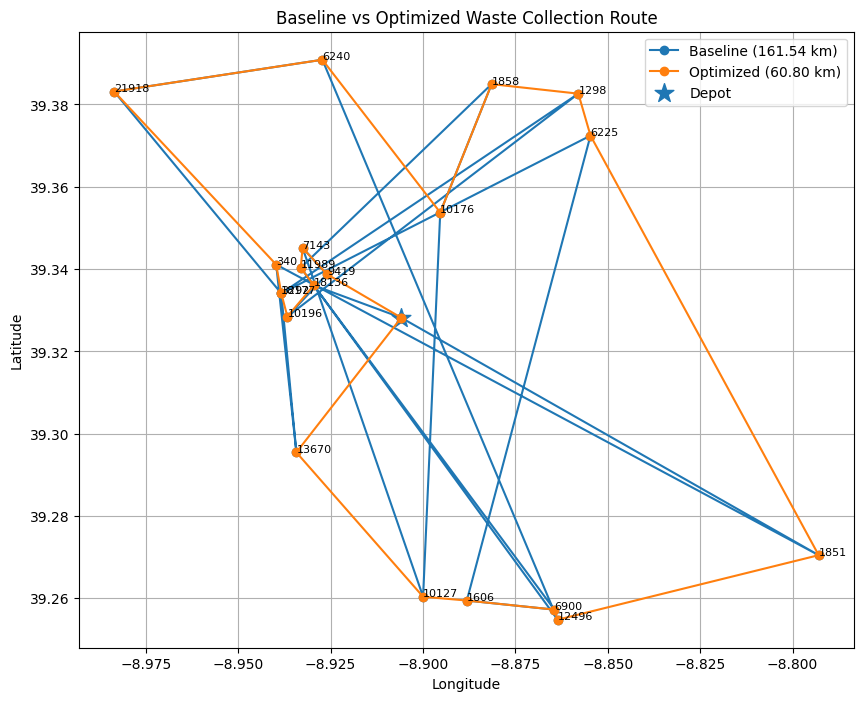

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# -----------------------------
# Plot baseline route
# -----------------------------
baseline_lats = [point[1] for point in baseline_route]
baseline_lons = [point[2] for point in baseline_route]

plt.plot(
    baseline_lons,
    baseline_lats,
    marker="o",
    label=f"Baseline ({baseline_distance:.2f} km)"
)

# -----------------------------
# Plot optimized route
# -----------------------------
optimized_lats = [points[i][1] for i in final_route]
optimized_lons = [points[i][2] for i in final_route]

plt.plot(
    optimized_lons,
    optimized_lats,
    marker="o",
    label=f"Optimized ({final_distance:.2f} km)"
)

# Depot
plt.scatter(
    depot_lon,
    depot_lat,
    marker="*",
    s=200,
    label="Depot"
)

# Labels
for _, row in route_df.iterrows():
    plt.annotate(
        str(int(row["Container_ID"])),
        (row["Longitude"], row["Latitude"]),
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Baseline vs Optimized Waste Collection Route")
plt.legend()
plt.grid(True)

plt.show()

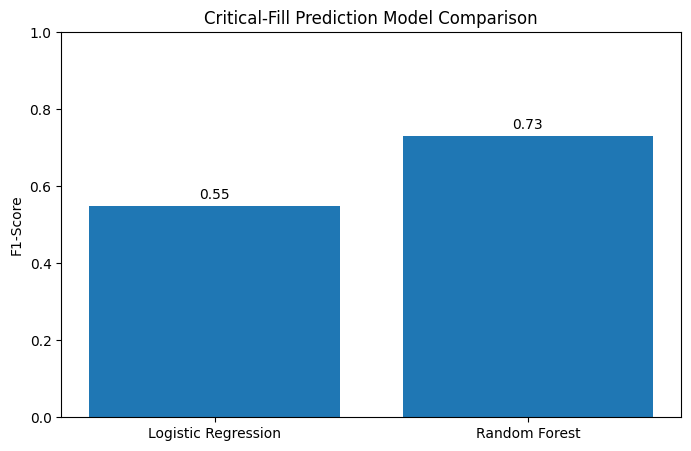

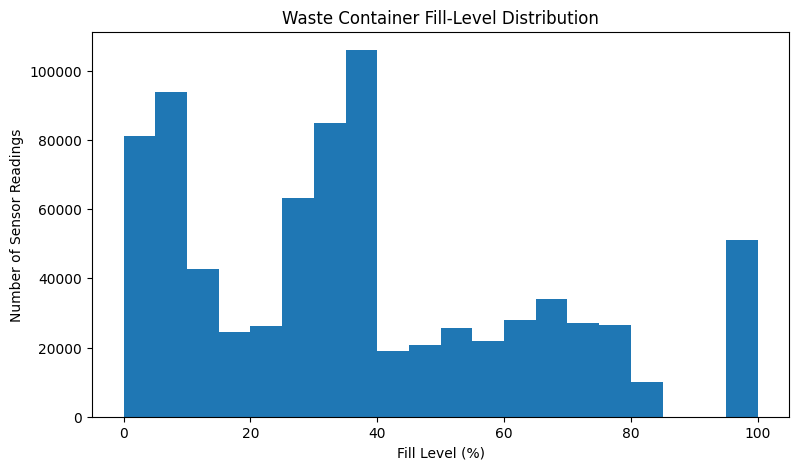

In [ ]:
# Model performance comparison

models = ["Logistic Regression", "Random Forest"]
f1_scores = [0.5475, 0.7300]

plt.figure(figsize=(8, 5))

plt.bar(models, f1_scores)

plt.ylabel("F1-Score")
plt.title("Critical-Fill Prediction Model Comparison")
plt.ylim(0, 1)

for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()
plt.figure(figsize=(9, 5))

plt.hist(
    model_df["Fill"],
    bins=20
)

plt.xlabel("Fill Level (%)")
plt.ylabel("Number of Sensor Readings")
plt.title("Waste Container Fill-Level Distribution")

plt.show()

In [ ]:
# Separate urgent bins and predictive-risk bins

urgent_bins = (
    latest_priority[
        latest_priority["Fill"] >= 80
    ]
    .sort_values("Priority_Score", ascending=False)
    .head(10)
    .copy()
)

early_warning_bins = (
    latest_priority[
        latest_priority["Fill"] < 80
    ]
    .sort_values("Critical_Probability", ascending=False)
    .head(10)
    .copy()
)

print("Urgent bins:", len(urgent_bins))
print("Early-warning bins:", len(early_warning_bins))
print("\n===== URGENT BINS =====")

print(
    urgent_bins[
        [
            "Container_ID",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)

print("\n===== EARLY-WARNING BINS =====")

print(
    early_warning_bins[
        [
            "Container_ID",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)

Urgent bins: 10
Early-warning bins: 10

===== URGENT BINS =====
 Container_ID  Fill  Critical_Probability  Priority_Score
         1851   100              0.899849        0.892925
          340   100              0.885457        0.890228
        13670   100              0.890005        0.874502
         3292   100              0.944894        0.862947
         1298   100              0.874269        0.838134
        10196   100              0.888230        0.836115
         9419   100              0.907416        0.833708
         7143   100              0.749356        0.832678
        10127   100              0.802742        0.829371
        10176   100              0.884486        0.823743

===== EARLY-WARNING BINS =====
 Container_ID  Fill  Critical_Probability  Priority_Score
         1857    75              0.956986        0.740993
        10175    79              0.956974        0.754987
        10114    75              0.955682        0.740341
        17908    77              0

In [ ]:
predictive_collection = pd.concat(
    [urgent_bins, early_warning_bins]
).drop_duplicates(
    subset="Container_ID"
)

print(
    "Total unique collection candidates:",
    predictive_collection["Container_ID"].nunique()
)

Total unique collection candidates: 20


In [ ]:
predictive_route_df = predictive_collection.merge(
    info_df,
    left_on="Container_ID",
    right_on="ID",
    how="left"
)

print(
    predictive_route_df[
        [
            "Container_ID",
            "Latitude",
            "Longitude",
            "Capacity",
            "WasteType",
            "Fill",
            "Critical_Probability",
            "Priority_Score"
        ]
    ].to_string(index=False)
)
print(
    "\nMissing coordinates:",
    predictive_route_df["Latitude"].isna().sum()
)

print(
    "Unique containers:",
    predictive_route_df["Container_ID"].nunique()
)


 Container_ID  Latitude  Longitude  Capacity                    WasteType  Fill  Critical_Probability  Priority_Score
         1851 39.270488  -8.792934    2500.0 Embalagens de papel e cartão   100              0.899849        0.892925
          340 39.341097  -8.939725    2500.0        Mistura de embalagens   100              0.885457        0.890228
        13670 39.295469  -8.934261    2500.0 Embalagens de papel e cartão   100              0.890005        0.874502
         3292 39.334103  -8.938347    2500.0        Mistura de embalagens   100              0.944894        0.862947
         1298 39.382631  -8.857967    2500.0        Mistura de embalagens   100              0.874269        0.838134
        10196 39.328481  -8.936697    2500.0 Embalagens de papel e cartão   100              0.888230        0.836115
         9419 39.338764  -8.925983    2500.0 Embalagens de papel e cartão   100              0.907416        0.833708
         7143 39.345147  -8.932584    2500.0        Mist

In [ ]:
# Create points for the predictive collection scenario

predictive_points = [
    ("Depot", depot_lat, depot_lon)
]

for _, row in predictive_route_df.iterrows():
    predictive_points.append(
        (
            row["Container_ID"],
            row["Latitude"],
            row["Longitude"]
        )
    )

print("Total locations:", len(predictive_points))
# Create distance matrix for predictive collection scenario

n_predictive = len(predictive_points)

predictive_distance_matrix = np.zeros(
    (n_predictive, n_predictive)
)

for i in range(n_predictive):
    for j in range(n_predictive):

        predictive_distance_matrix[i, j] = haversine(
            predictive_points[i][1],
            predictive_points[i][2],
            predictive_points[j][1],
            predictive_points[j][2]
        )

print(
    "Predictive distance matrix shape:",
    predictive_distance_matrix.shape
)
# Create baseline route using priority order

predictive_baseline_df = (
    predictive_route_df
    .sort_values(
        "Priority_Score",
        ascending=False
    )
    .copy()
)

predictive_baseline_route = [0]

for _, row in predictive_baseline_df.iterrows():

    container_id = row["Container_ID"]

    # Find the corresponding point index
    for i, point in enumerate(predictive_points):
        if point[0] == container_id:
            predictive_baseline_route.append(i)
            break

# Return to depot
predictive_baseline_route.append(0)

print("Predictive Baseline Route:")

for i in predictive_baseline_route:
    print(predictive_points[i][0], end=" → ")
predictive_baseline_distance = calculate_route_distance(
    predictive_baseline_route,
    predictive_distance_matrix
)

print(
    f"\nPredictive baseline distance: "
    f"{predictive_baseline_distance:.2f} km"
)

# Nearest Neighbor for predictive collection scenario

unvisited = set(range(1, n_predictive))
current = 0

predictive_nn_route = [0]

while unvisited:

    next_point = min(
        unvisited,
        key=lambda x: predictive_distance_matrix[current, x]
    )

    predictive_nn_route.append(next_point)
    unvisited.remove(next_point)

    current = next_point

predictive_nn_route.append(0)

predictive_nn_distance = calculate_route_distance(
    predictive_nn_route,
    predictive_distance_matrix
)

print(
    f"Nearest Neighbor distance: "
    f"{predictive_nn_distance:.2f} km"
)

# Apply 2-opt optimization to the predictive Nearest Neighbor route
predictive_final_route, predictive_final_distance = two_opt(
    predictive_nn_route,
    predictive_distance_matrix
)

print(
    f"2-opt optimized distance: "
    f"{predictive_final_distance:.2f} km"
)

print("\nFinal Predictive Optimized Route:")

for i in predictive_final_route:
    print(
        predictive_points[i][0],
        end=" → "
    )

Total locations: 21
Predictive distance matrix shape: (21, 21)
Predictive Baseline Route:
Depot → 1851 → 340 → 13670 → 3292 → 1298 → 10196 → 9419 → 7143 → 10127 → 10176 → 10175 → 10170 → 17908 → 11827 → 1857 → 10114 → 10799 → 904 → 12710 → 11553 → Depot → 
Predictive baseline distance: 140.80 km
Nearest Neighbor distance: 65.90 km
2-opt optimized distance: 59.36 km

Final Predictive Optimized Route:
Depot → 10114 → 904 → 340 → 12710 → 10170 → 3292 → 10196 → 13670 → 17908 → 10127 → 1851 → 10799 → 1857 → 1298 → 10176 → 10175 → 11827 → 11553 → 7143 → 9419 → Depot → 

In [ ]:
# Predictive scenario fuel estimation

predictive_fuel_consumption = 0.30  # L/km

predictive_baseline_fuel = (
    predictive_baseline_distance
    * predictive_fuel_consumption
)

predictive_optimized_fuel = (
    predictive_final_distance
    * predictive_fuel_consumption
)

predictive_fuel_saved = (
    predictive_baseline_fuel
    - predictive_optimized_fuel
)

print(
    f"Baseline estimated fuel: "
    f"{predictive_baseline_fuel:.2f} L"
)

print(
    f"Optimized estimated fuel: "
    f"{predictive_optimized_fuel:.2f} L"
)

print(
    f"Estimated fuel saved: "
    f"{predictive_fuel_saved:.2f} L"
)
# Predictive scenario CO2 estimation

predictive_co2_factor = 2.68  # kg CO2/L diesel

predictive_baseline_co2 = (
    predictive_baseline_fuel
    * predictive_co2_factor
)

predictive_optimized_co2 = (
    predictive_optimized_fuel
    * predictive_co2_factor
)

predictive_co2_saved = (
    predictive_baseline_co2
    - predictive_optimized_co2
)

print(
    f"Baseline estimated CO2: "
    f"{predictive_baseline_co2:.2f} kg"
)

print(
    f"Optimized estimated CO2: "
    f"{predictive_optimized_co2:.2f} kg"
)

print(
    f"Estimated CO2 saved: "
    f"{predictive_co2_saved:.2f} kg"
)

Baseline estimated fuel: 42.24 L
Optimized estimated fuel: 17.81 L
Estimated fuel saved: 24.43 L
Baseline estimated CO2: 113.21 kg
Optimized estimated CO2: 47.73 kg
Estimated CO2 saved: 65.48 kg
